In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
base_path='/Users/ashhadulislam/projects/KTH/collabs/Karolinska/josefine_parkinson/data/FullBrain'
# base path should contain the excel sheet at the top level and the folder CIR_PD_wholebrain_ts
df_meta=pd.read_excel(f'{base_path}/pd_longitudinal_metadata_short.xlsx')

In [3]:
id_bl=df_meta['id_bl'].values
id_fu=df_meta['id_fu'].values

patient_mapping_full = {
    f'NatMEG_{str(id_bl[i]).zfill(4)}': f'NatMEG_{str(id_fu[i]).zfill(4)}'
    for i in range(len(id_bl))
}


In [4]:
id_bl

array([355, 366, 392, 523, 524, 533, 534, 537, 540, 543, 544, 545, 547,
       553, 559, 562, 563, 566, 568, 569, 570, 572, 573, 575, 576, 579,
       580, 583, 584, 586, 587, 589, 592, 596, 598, 601, 604, 606, 607,
       608, 611, 614, 621, 624, 625, 627, 628, 637, 641, 642, 643, 644,
       647, 652, 661, 662, 715, 739])

In [5]:
data_path=f'{base_path}/CIR_PD_wholebrain_ts'
base_line='wholebrain_ts_aparc_dSPM_bl'
follow_up='wholebrain_ts_aparc_dSPM_fu'

base_line_path=f'{data_path}/{base_line}'
base_line_patients=os.listdir(base_line_path)

follow_up_path=f'{data_path}/{follow_up}'
follow_up_patients=os.listdir(follow_up_path)

In [6]:

if '.DS_Store' in base_line_patients:
    base_line_patients.remove('.DS_Store')

if '.DS_Store' in follow_up_patients:
    follow_up_patients.remove('.DS_Store')

In [7]:
bl_pat_file_reference_sequence={}
fu_pat_file_reference_sequence={}

In [8]:
datas=[]
for bl_pat in base_line_patients:
    bl_pat_file_test_sequence=''
    fu_pat_file_test_sequence=''
    if bl_pat not in patient_mapping_full:
        continue
    fu_pat=patient_mapping_full[bl_pat]
    bl_pat_int=int(bl_pat.split('NatMEG_')[-1])
    fu_pat_int=int(fu_pat.split('NatMEG_')[-1])

    df_meta_selected=df_meta[(df_meta['id_bl']==bl_pat_int) & (df_meta['id_fu']==fu_pat_int)]
    updrs_bl=df_meta_selected['updrs_bl'].values[0]
    updrs_fu=df_meta_selected['updrs_fu'].values[0]
    print(bl_pat,fu_pat)
    bl_pat_files=os.listdir(f'{base_line_path}/{bl_pat}')
    fu_pat_files=os.listdir(f'{follow_up_path}/{fu_pat}')
    bl_pat_files.sort()
    fu_pat_files.sort()
    bl_pat_array=[]
    for bl_pat_file_index,bl_pat_file in enumerate(bl_pat_files):        
        if bl_pat_file not in bl_pat_file_reference_sequence:
            bl_pat_file_reference_sequence[bl_pat_file]=bl_pat_file_index
        else:
            assert bl_pat_file_reference_sequence[bl_pat_file]==bl_pat_file_index             
        bl_pat_file_path=f'{base_line_path}/{bl_pat}/{bl_pat_file}'
        arr=np.load(bl_pat_file_path)
        bl_pat_array.append(arr)
    bl_pat_array=np.array(bl_pat_array)
    print(bl_pat_array.shape)


    fu_pat_array=[]
    for fu_pat_file_index, fu_pat_file in enumerate(fu_pat_files):
        if fu_pat_file not in fu_pat_file_reference_sequence:
            fu_pat_file_reference_sequence[fu_pat_file]=fu_pat_file_index

        else:
            assert fu_pat_file_reference_sequence[fu_pat_file]==fu_pat_file_index
                
        fu_pat_file_path=f'{follow_up_path}/{fu_pat}/{fu_pat_file}'
        arr=np.load(fu_pat_file_path)
        fu_pat_array.append(arr)
    fu_pat_array=np.array(fu_pat_array)
    print(fu_pat_array.shape)
    case_data={
        'bl_pat_int':bl_pat_int,
        'fu_pat_int':fu_pat_int,
        'bl_pat_array':bl_pat_array,
        'fu_pat_array':fu_pat_array,
        'updrs_bl':updrs_bl,
        'updrs_fu':updrs_fu
               }
    datas.append(case_data)

NatMEG_0568 NatMEG_1165
(68, 300000)
(68, 162000)
NatMEG_0566 NatMEG_1042
(68, 298000)
(68, 298000)
NatMEG_0592 NatMEG_1133
(68, 196000)
(68, 299000)
NatMEG_0559 NatMEG_1107
(68, 298000)
(68, 299000)
NatMEG_0355 NatMEG_0531
(68, 176000)
(68, 299000)
NatMEG_0569 NatMEG_1148
(68, 189000)
(68, 299000)
NatMEG_0533 NatMEG_1098
(68, 300000)
(68, 300000)
NatMEG_0739 NatMEG_1158
(68, 298000)
(68, 298000)
NatMEG_0534 NatMEG_1092
(68, 261000)
(68, 297000)
NatMEG_0642 NatMEG_1166
(68, 298000)
(68, 299000)
NatMEG_0611 NatMEG_1058
(68, 299000)
(68, 204000)
NatMEG_0627 NatMEG_1159
(68, 204000)
(68, 299000)
NatMEG_0643 NatMEG_1046
(68, 300000)
(68, 227000)
NatMEG_0644 NatMEG_1161
(68, 298000)
(68, 298000)
NatMEG_0621 NatMEG_1112
(68, 299000)
(68, 298000)
NatMEG_0628 NatMEG_1117
(68, 298000)
(68, 299000)
NatMEG_0604 NatMEG_1163
(68, 299000)
(68, 294000)
NatMEG_0661 NatMEG_1164
(68, 300000)
(68, 298000)
NatMEG_0715 NatMEG_1085
(68, 298000)
(68, 298000)
NatMEG_0580 NatMEG_1077
(68, 291000)
(68, 286000)


In [9]:
len(datas)
datas=datas[:5]

In [10]:
datas[0]['bl_pat_array'].shape

(68, 300000)

In [11]:
combined_data=[]
sumup=0
for data in datas:
    #print(data['bl_pat_array'].shape)
    combined_data.append(data['bl_pat_array'])
    sumup+=data['bl_pat_array'].shape[1]
combined_data=np.concat(combined_data,axis=1)
print(combined_data.shape)
assert combined_data.shape[1]==sumup

(68, 1268000)


In [12]:
def get_threshold(data_matrix,min_threshold=0.05, max_threshold=0.95):
    # expecting an nXm matrix here where n is number of rows and m is number of columns
    # merged the time series data so n should be 68 and m should be really really long
    # for each n then find the min and max threshold
    # if min_threshold=0.05 implies 5% of data considered to be outlier below minimum
    # if max_threshold=0.95 implies 95% of data considered to be outlier above minimum
    # return an array of min and max threshold in absolute value for each column
    min_thresholds = np.quantile(data_matrix, min_threshold, axis=1)
    max_thresholds = np.quantile(data_matrix, max_threshold, axis=1)
    return min_thresholds, max_thresholds    
    


In [13]:
min_thresholds, max_thresholds = get_threshold(combined_data,min_threshold=0.05, max_threshold=0.95)
# slow function

In [14]:
max_thresholds

array([1.8461115 , 1.1174685 , 2.7203975 , 1.9080187 , 0.5299776 ,
       0.7465717 , 3.201206  , 1.049946  , 4.4895835 , 4.2963395 ,
       2.6221404 , 2.0396352 , 1.4363152 , 0.91857517, 0.5295089 ,
       0.5492243 , 1.2827604 , 1.2467111 , 3.6738133 , 3.5746949 ,
       4.037508  , 3.2406454 , 1.5076915 , 1.1185472 , 2.3072581 ,
       2.2272162 , 1.1533171 , 1.1514969 , 0.9291699 , 1.2807078 ,
       0.6738906 , 0.7425667 , 3.9245899 , 3.3739357 , 5.294122  ,
       5.3348093 , 1.0934261 , 0.7406983 , 1.7289456 , 0.90700465,
       0.8141588 , 0.6457049 , 2.0394695 , 1.0424962 , 0.492792  ,
       0.5525704 , 1.6676593 , 2.3252792 , 0.7652774 , 0.7128727 ,
       2.415578  , 2.2293735 , 2.4798353 , 2.5921516 , 0.28561518,
       0.2408376 , 0.34610173, 0.52987796, 1.1070592 , 1.0080395 ,
       1.6083391 , 0.68989456, 0.31401142, 0.39460734, 1.4923702 ,
       3.0971518 , 3.2272742 , 3.5995493 ], dtype=float32)

In [15]:
def normalize(data_matrix,min_thresholds,max_thresholds,floor=0,ceiling=1):
    # expecting an nXm matrix here where n is number of rows and m is number of columns
    # merged the time series data so n should be 68 and m should be really really long
    # for each n then utilize the corresponding min and max threshold to normalize the data between floor and ceiling
    # any data below min_threshold to be clamped to floor
    # any data above max_threshold to be clamped to ceiling

    min_thresholds = min_thresholds[:, None]
    max_thresholds = max_thresholds[:, None]
    data_matrix_normed = (
        (data_matrix - min_thresholds) /
        (max_thresholds - min_thresholds)
    )

    data_matrix_normed = np.clip(
        data_matrix_normed,
        floor,
        ceiling
    )
    return data_matrix_normed

In [16]:
combined_data_normed= normalize(combined_data,min_thresholds, max_thresholds, floor=0, ceiling=1)

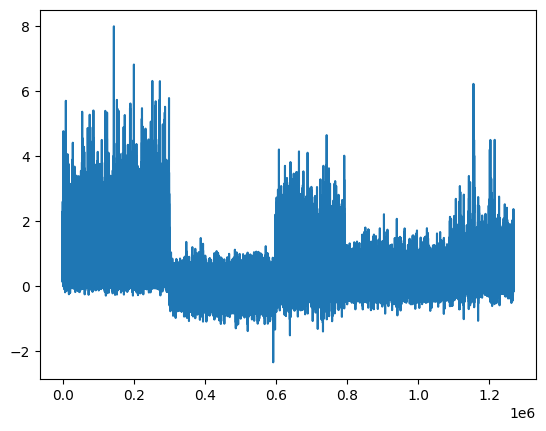

In [17]:
plt.plot(combined_data[0])

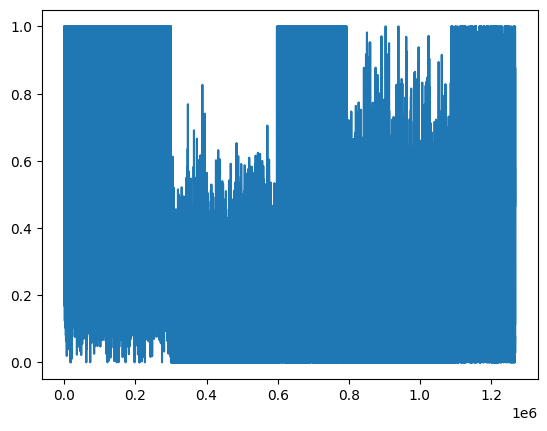

In [18]:
plt.plot(combined_data_normed[0])

### Every patient should be normalized on its own

In [19]:
combined_data_normed=[]
for data in datas:
    print(data.keys())
    print(data['bl_pat_array'].shape)
    min_thresholds, max_thresholds = get_threshold(data['bl_pat_array'],min_threshold=0.01, max_threshold=0.99)
    normalized_data = normalize(data['bl_pat_array'],min_thresholds, max_thresholds, floor=0, ceiling=1)
    combined_data_normed.append(normalized_data)
combined_data_normed=np.concat(combined_data_normed,axis=1)

dict_keys(['bl_pat_int', 'fu_pat_int', 'bl_pat_array', 'fu_pat_array', 'updrs_bl', 'updrs_fu'])
(68, 300000)
dict_keys(['bl_pat_int', 'fu_pat_int', 'bl_pat_array', 'fu_pat_array', 'updrs_bl', 'updrs_fu'])
(68, 298000)
dict_keys(['bl_pat_int', 'fu_pat_int', 'bl_pat_array', 'fu_pat_array', 'updrs_bl', 'updrs_fu'])
(68, 196000)
dict_keys(['bl_pat_int', 'fu_pat_int', 'bl_pat_array', 'fu_pat_array', 'updrs_bl', 'updrs_fu'])
(68, 298000)
dict_keys(['bl_pat_int', 'fu_pat_int', 'bl_pat_array', 'fu_pat_array', 'updrs_bl', 'updrs_fu'])
(68, 176000)


-0.19692451 1.9561197


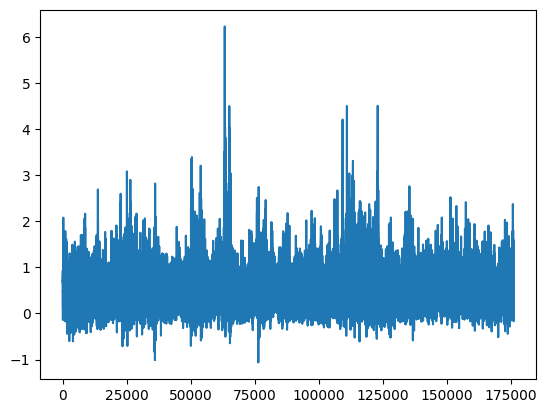

In [20]:
print(min_thresholds[0],max_thresholds[0])
plt.plot(data['bl_pat_array'][0])

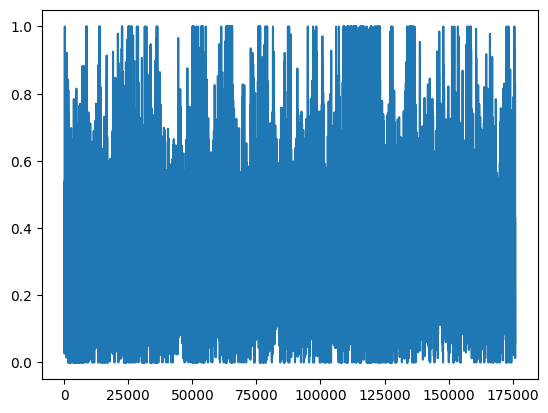

In [21]:
plt.plot(normalized_data[0])

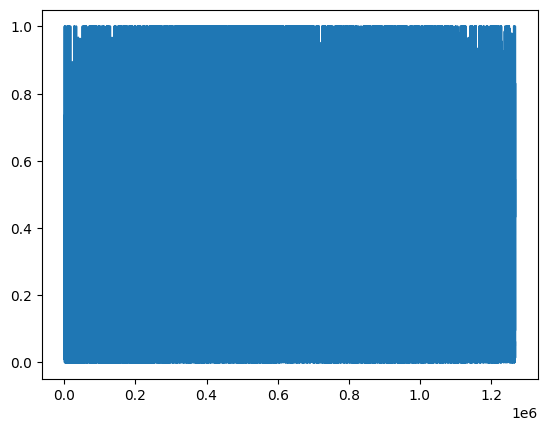

In [22]:
plt.plot(combined_data_normed[0])